In [62]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np


In [63]:
# Step 1: Define a simple backbone network for SSD
def build_backbone(input_shape=(300, 300, 3)):
    inputs = tf.keras.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    base_model = models.Model(inputs, x, name="SSD_Backbone")
    return base_model


In [64]:
# Step 2: Define SSD prediction head for class and bounding box predictions
def ssd_head(x, num_classes, num_boxes):
    class_head = layers.Conv2D(num_boxes * num_classes, (3, 3), padding="same")(x)
    class_head = layers.Reshape((-1, num_classes))(class_head)

    box_head = layers.Conv2D(num_boxes * 4, (3, 3), padding="same")(x)  # 4 values for (x, y, w, h)
    box_head = layers.Reshape((-1, 4))(box_head)

    return class_head, box_head


In [65]:
# Step 3: Build the SSD model combining backbone, SSD heads, and multi-scale feature maps
def build_ssd_model(input_shape=(300, 300, 3), num_classes=4, num_boxes=6):
    # Backbone network
    base = build_backbone(input_shape)
    x = base.output  # Starting feature map from the backbone

    # Multi-scale feature maps for detection heads
    class_outputs, box_outputs = [], []
    for i in range(3):  # 3 scales for simplicity
        class_head, box_head = ssd_head(x, num_classes, num_boxes)
        class_outputs.append(class_head)
        box_outputs.append(box_head)

        # Downsample the feature map for next scale
        x = layers.Conv2D(128, (3, 3), strides=2, padding="same")(x)

    # Concatenate outputs across all scales
    classes_concat = layers.Concatenate(axis=1)(class_outputs)
    boxes_concat = layers.Concatenate(axis=1)(box_outputs)

    # Define the final SSD model
    ssd_model = models.Model(inputs=base.input, outputs=[classes_concat, boxes_concat])
    return ssd_model

# Instantiate SSD model
ssd_model = build_ssd_model()
ssd_model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 300, 300,  │        896 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 150, 150,  │          0 │ conv2d_24[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 150, 150,  │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 75, 75,    │          0 │ conv2d_25[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 75, 75,    │     73,856 │ max_pooling2d_5[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 38, 38,    │    147,584 │ conv2d_26[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 19, 19,    │    147,584 │ conv2d_29[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 75, 75,    │     27,672 │ conv2d_26[0][0]   │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 38, 38,    │     27,672 │ conv2d_29[0][0]   │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 19, 19,    │     27,672 │ conv2d_32[0][0]   │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 75, 75,    │     27,672 │ conv2d_26[0][0]   │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 38, 38,    │     27,672 │ conv2d_29[0][0]   │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 19, 19,    │     27,672 │ conv2d_32[0][0]   │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_12          │ (None, 33750, 4)  │          0 │ conv2d_27[0][0]   │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_14          │ (None, 8664, 4)   │          0 │ conv2d_30[0][0]   │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_16          │ (None, 2166, 4)   │          0 │ conv2d_33[0][0] 

 Total params: 554,448 (2.12 MB)

 Trainable params: 554,448 (2.12 MB)

 Non-trainable params: 0 (0.00 B)

### Step 4: Load and Preprocess Image Data

Original image path: /content/TrainSorghumWeed-4-_JPG.rf.8e272d07c8fff61b0fcb0af51726033e.jpg
Preprocessed image shape: (1, 300, 300, 3)


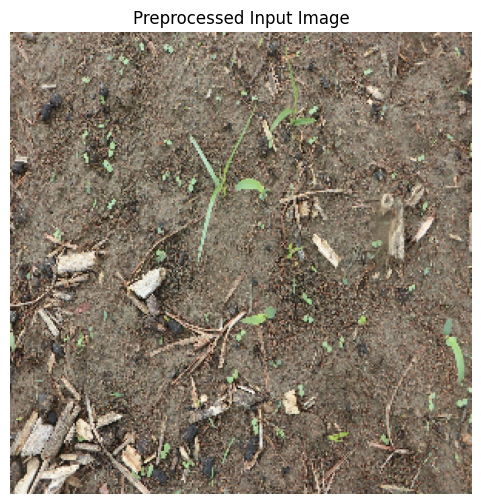

In [66]:
import matplotlib.pyplot as plt

image_path = '/content/TrainSorghumWeed-4-_JPG.rf.8e272d07c8fff61b0fcb0af51726033e.jpg'

def preprocess_image(image_path, target_size=(300, 300)):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, target_size)
    img = img / 255.0  # Normalize to [0, 1]
    return img

# Load and preprocess an example image
input_image = preprocess_image(image_path)

# Add a batch dimension (model expects a batch of images)
input_image_batch = tf.expand_dims(input_image, axis=0)

print(f"Original image path: {image_path}")
print(f"Preprocessed image shape: {input_image_batch.shape}")

# Display the preprocessed image
plt.figure(figsize=(6,6))
plt.imshow(input_image.numpy())
plt.title("Preprocessed Input Image")
plt.axis('off')
plt.show()

### Step 5: Make Predictions with the SSD Model

In [67]:
# Make predictions
class_preds, box_preds = ssd_model.predict(input_image_batch)

print("Class predictions shape:", class_preds.shape)
print("Box predictions shape:", box_preds.shape)

# You would typically have a post-processing step here to decode the raw predictions
# into actual bounding boxes and class labels with confidence scores.
# For now, let's just show the raw predictions.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step
Class predictions shape: (1, 44580, 4)
Box predictions shape: (1, 44580, 4)


### Step 7: Download and Unzip Data from Google Drive

In [68]:
# Install gdown for downloading from Google Drive
%pip install gdown

In [69]:
import gdown
import os

# Google Drive file ID for the provided link
file_id = '1OMzX1cDWbdyG3YtbyqfUEjXp57kj-9Yo'
output_filename = 'dataset.zip'

# Download the file
gdown.download(id=file_id, output=output_filename, quiet=False)

print(f"Downloaded {output_filename}")

# Unzip the file
if os.path.exists(output_filename):
    # Create a directory to extract into, if you want to keep things organized
    extract_dir = 'dataset'
    os.makedirs(extract_dir, exist_ok=True)

    # Unzip command
    # The ! prefix runs a shell command
    !unzip -o {output_filename} -d {extract_dir}
    print(f"Unzipped contents to {extract_dir}/")

    # Optionally, remove the zip file after extraction
    # os.remove(output_filename)
    # print(f"Removed {output_filename}")
else:
    print(f"Error: {output_filename} not found for unzipping.")

Downloading...
From (original): https://drive.google.com/uc?id=1OMzX1cDWbdyG3YtbyqfUEjXp57kj-9Yo
From (redirected): https://drive.google.com/uc?id=1OMzX1cDWbdyG3YtbyqfUEjXp57kj-9Yo&confirm=t&uuid=3c42238f-ce6e-4418-ba45-ec23a70a8de6
To: /content/dataset.zip
100%|██████████| 323M/323M [00:02<00:00, 125MB/s]


Downloaded dataset.zip
Archive:  dataset.zip
 extracting: dataset/test/images/TrainSorghumWeed-90-_JPG.rf.a4c03a9a1c7bb2057287a8f168e66622.jpg  
 extracting: dataset/test/images/TrainSorghumWeed-37-_JPG.rf.ca7e1f53dffbe9ca9970419361b49c5f.jpg  
 extracting: dataset/test/images/TrainSorghumWeed-100-_JPG.rf.17964329b70358656b3093a1ca2cfbcf.jpg  
 extracting: dataset/test/images/TrainSorghumWeed-34-_JPG.rf.5635012f57fe51dd4b06ddd97fde6287.jpg  
 extracting: dataset/test/images/TrainSorghumWeed-51-_JPG.rf.4045b07ed46016287b7cf2b1fa668e91.jpg  
 extracting: dataset/test/images/TrainSorghumWeed-22-_JPG.rf.5d2fec2911387eeb3b59de8088e67a02.jpg  
 extracting: dataset/train/images/TrainSorghumWeed-27-_JPG.rf.17b47c8ff3543f45f4ba90944a4fde46.jpg  
 extracting: dataset/train/images/TrainSorghumWeed-23-_JPG.rf.e175445fde733a6df042e70a94783308.jpg  
 extracting: dataset/train/images/TrainSorghumWeed-73-_JPG.rf.dc8f4013d07a94059f6f2f0d090d2c51.jpg  
 extracting: dataset/test/images/TrainSorghumWeed-4

### Step 8: Prepare Dataset for Training

In [70]:
import yaml

# Path to the data.yaml file
yaml_file_path = os.path.join(extract_dir, 'data.yaml')

# Load the YAML file
with open(yaml_file_path, 'r') as file:
    data_yaml = yaml.safe_load(file)

# Extract class names and number of classes
class_names = data_yaml['names']
num_classes_dataset = len(class_names)

print("Class Names from data.yaml:", class_names)
print("Number of classes from data.yaml:", num_classes_dataset)

# Update num_classes in the SSD model if necessary
# Note: The SSD model was built with num_classes=21 (20 object classes + 1 background)
# If your dataset has a different number of classes, you'd need to rebuild the model.
# For now, let's assume the SSD model's num_classes aligns with the dataset's num_classes + 1 for background.
# The original SSD model has 21 classes (20 objects + 1 background). If the dataset has 3 classes, then
# the SSD model's actual object classes should be 3, making total classes 4 (3 objects + 1 background).
# We will adjust `num_classes` in the model definition later if needed. For now, we adjust example_class_names.
if num_classes != num_classes_dataset + 1:
    print(f"Warning: SSD model has {num_classes} classes, but dataset has {num_classes_dataset}. Adjusting example_class_names.")
    # Re-align example_class_names for visualization, assuming background is class 0
    example_class_names = ['background'] + class_names

# Corrected paths to images and labels relative to the extract_dir
train_image_dir = os.path.join(extract_dir, 'train', 'images')
train_label_dir = os.path.join(extract_dir, 'train', 'labels')

val_image_dir = os.path.join(extract_dir, 'valid', 'images')
val_label_dir = os.path.join(extract_dir, 'valid', 'labels')

test_image_dir = os.path.join(extract_dir, 'test', 'images')
test_label_dir = os.path.join(extract_dir, 'test', 'labels')

print(f"Train images: {train_image_dir}")
print(f"Train labels: {train_label_dir}")


Class Names from data.yaml: ['Grass', 'Sorghum', 'Weed']
Number of classes from data.yaml: 3
Train images: dataset/train/images
Train labels: dataset/train/labels


In [71]:
import glob

# Function to get sorted lists of image and label paths
def get_paths_list(image_dir, label_dir):
    image_paths = sorted(glob.glob(os.path.join(image_dir, '*.jpg')))
    label_paths = [os.path.join(label_dir, os.path.basename(img_path).replace('.jpg', '.txt')) for img_path in image_paths]
    return image_paths, label_paths

# Generate lists for training data
train_image_paths_list, train_label_paths_list = get_paths_list(train_image_dir, train_label_dir)
print(f"Found {len(train_image_paths_list)} training images and {len(train_label_paths_list)} training labels.")

# Generate lists for validation data
val_image_paths_list, val_label_paths_list = get_paths_list(val_image_dir, val_label_dir)
print(f"Found {len(val_image_paths_list)} validation images and {len(val_label_paths_list)} validation labels.")

# Generate lists for test data
test_image_paths_list, test_label_paths_list = get_paths_list(test_image_dir, test_label_dir)
print(f"Found {len(test_image_paths_list)} test images and {len(test_label_paths_list)} test labels.")


Found 70 training images and 70 training labels.
Found 15 validation images and 15 validation labels.
Found 15 test images and 15 test labels.


### Switching to PyTorch for Training Loop

In [72]:
import torch
from torch.utils.data import Dataset, DataLoader
import os

# Function to parse YOLO annotation files and return PyTorch tensors
def parse_yolo_annotation_pytorch(label_path, img_width, img_height):
    boxes = []
    labels = []
    # Decode the TensorFlow string Tensor to a Python string, if it's still coming from tf.py_function
    if isinstance(label_path, bytes):
        label_path = label_path.decode('utf-8')

    try:
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                class_id = int(parts[0])
                # YOLO format: class_id center_x center_y width height (normalized)
                center_x, center_y, width, height = map(float, parts[1:])

                # Convert to (ymin, xmin, ymax, xmax) normalized format
                xmin = (center_x - width / 2)
                ymin = (center_y - height / 2)
                xmax = (center_x + width / 2)
                ymax = (center_y + height / 2)

                boxes.append([ymin, xmin, ymax, xmax])
                labels.append(class_id)
    except FileNotFoundError:
        print(f"Warning: Label file not found for {label_path}")
        return torch.empty((0, 4), dtype=torch.float32), torch.empty((0,), dtype=torch.int64)

    if not boxes:
        return torch.empty((0, 4), dtype=torch.float32), torch.empty((0,), dtype=torch.int64)

    return torch.tensor(boxes, dtype=torch.float32), torch.tensor(labels, dtype=torch.int64)

print("PyTorch imports and parse_yolo_annotation_pytorch function defined.")

PyTorch imports and parse_yolo_annotation_pytorch function defined.


### Define PyTorch Custom Dataset

In [73]:
import cv2
from torchvision import transforms

class WeedDetectionDataset(Dataset):
    def __init__(self, image_paths, label_paths, transform=None, target_size=(300, 300)):
        self.image_paths = image_paths
        self.label_paths = label_paths
        self.transform = transform
        self.target_size = target_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label_path = self.label_paths[idx]

        # Load image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        original_h, original_w, _ = img.shape

        # Resize image
        img = cv2.resize(img, self.target_size)
        img = transforms.ToTensor()(img) # Converts to C, H, W and normalizes to [0, 1]

        # Parse labels using the PyTorch-compatible function
        # We pass original_w and original_h for potential denormalization if needed inside parse_yolo_annotation_pytorch
        # However, parse_yolo_annotation_pytorch already returns normalized [ymin, xmin, ymax, xmax] so these aren't strictly used for output
        boxes, labels = parse_yolo_annotation_pytorch(label_path, original_w, original_h)

        # Apply further transformations if provided
        if self.transform:
            img, boxes, labels = self.transform(img, boxes, labels) # Custom transform should handle both

        return img, (boxes, labels)

print("WeedDetectionDataset class defined.")

WeedDetectionDataset class defined.


### Define `collate_fn` and create `DataLoader`s

In [74]:
# Instantiate datasets
train_dataset_pt = WeedDetectionDataset(train_image_paths_list, train_label_paths_list)
val_dataset_pt = WeedDetectionDataset(val_image_paths_list, val_label_paths_list)
test_dataset_pt = WeedDetectionDataset(test_image_paths_list, test_label_paths_list)

print("PyTorch Datasets instantiated.")

def collate_fn(batch):
    images = []
    targets = []
    for img, (boxes, labels) in batch:
        images.append(img)
        targets.append({'boxes': boxes, 'labels': labels})
    # Stack images into a batch tensor
    images = torch.stack(images, 0)
    return images, targets

batch_size = 16 # You can adjust this

train_loader = DataLoader(train_dataset_pt,
                            batch_size=batch_size,
                            shuffle=True,
                            collate_fn=collate_fn)

val_loader = DataLoader(val_dataset_pt,
                          batch_size=batch_size,
                          shuffle=False,
                          collate_fn=collate_fn)

test_loader = DataLoader(test_dataset_pt,
                           batch_size=batch_size,
                           shuffle=False,
                           collate_fn=collate_fn)

print(f"DataLoaders created with batch size: {batch_size}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")

# Example of iterating through a batch
# For demonstration, uncomment if you want to see a batch structure
# for images, targets in train_loader:
#     print(f"Batch Images shape: {images.shape}")
#     print(f"Batch Targets (first item): {targets[0]}")
#     break


PyTorch Datasets instantiated.
DataLoaders created with batch size: 16
Number of training batches: 5
Number of validation batches: 1
Number of test batches: 1


In [75]:
print("\n--- Verifying Dataset Paths and Integrity ---")

def verify_paths(image_paths, label_paths, dataset_name):
    print(f"\nVerifying {dataset_name} dataset...")
    missing_images = []
    missing_labels = []

    # Ensure image_paths and label_paths are lists
    if not isinstance(image_paths, list) or not isinstance(label_paths, list):
        print(f"  Error: Expected lists of paths for {dataset_name}, but got {type(image_paths)} and {type(label_paths)}.")
        return

    for i, img_path in enumerate(image_paths):
        if not os.path.exists(img_path):
            missing_images.append(img_path)
        if i < len(label_paths) and not os.path.exists(label_paths[i]): # Labels are collected in parallel, so index should match
            missing_labels.append(label_paths[i])

    if missing_images:
        print(f"  {len(missing_images)} missing image files in {dataset_name}. First 5: {missing_images[:5]}")
    else:
        print(f"  All {len(image_paths)} image files in {dataset_name} found.")

    if missing_labels:
        print(f"  {len(missing_labels)} missing label files in {dataset_name}. First 5: {missing_labels[:5]}")
    else:
        print(f"  All {len(label_paths)} label files in {dataset_name} found.")

    if image_paths:
        print(f"  Example {dataset_name} Image Path: {image_paths[0]}")
        print(f"  Example {dataset_name} Label Path: {label_paths[0]}")
    else:
        print(f"  No {dataset_name} data to show examples for.")

# Verify each set
verify_paths(train_image_paths_list, train_label_paths_list, 'Training')
verify_paths(val_image_paths_list, val_label_paths_list, 'Validation')
verify_paths(test_image_paths_list, test_label_paths_list, 'Test')


--- Verifying Dataset Paths and Integrity ---

Verifying Training dataset...
  All 70 image files in Training found.
  All 70 label files in Training found.
  Example Training Image Path: dataset/train/images/TrainSorghumWeed-1-_JPG.rf.889d3883373550f02a2be8480f483ac6.jpg
  Example Training Label Path: dataset/train/labels/TrainSorghumWeed-1-_JPG.rf.889d3883373550f02a2be8480f483ac6.txt

Verifying Validation dataset...
  All 15 image files in Validation found.
  All 15 label files in Validation found.
  Example Validation Image Path: dataset/valid/images/TrainSorghumWeed-15-_JPG.rf.c587e26b9a47342e73457d67018473ef.jpg
  Example Validation Label Path: dataset/valid/labels/TrainSorghumWeed-15-_JPG.rf.c587e26b9a47342e73457d67018473ef.txt

Verifying Test dataset...
  All 15 image files in Test found.
  All 15 label files in Test found.
  Example Test Image Path: dataset/test/images/TrainSorghumWeed-100-_JPG.rf.17964329b70358656b3093a1ca2cfbcf.jpg
  Example Test Label Path: dataset/test/lab

### Step 6: Define the SSD Model in PyTorch

In [76]:
import torch.nn as nn
import torch.nn.functional as F

# Step 1: Define a simple backbone network for SSD in PyTorch
class PyTorchSSDBackbone(nn.Module):
    def __init__(self):
        super(PyTorchSSDBackbone, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()

    def forward(self, x):
        x = self.relu1(self.conv1(x))
        x = self.pool1(x)
        x = self.relu2(self.conv2(x))
        x = self.pool2(x)
        x = self.relu3(self.conv3(x))
        return x

# Step 2: Define PyTorch SSD prediction head for class and bounding box predictions
class PyTorchSSDHead(nn.Module):
    def __init__(self, in_channels, num_classes, num_boxes):
        super(PyTorchSSDHead, self).__init__()
        self.num_classes = num_classes
        self.num_boxes = num_boxes

        self.class_head = nn.Conv2d(in_channels, num_boxes * num_classes, kernel_size=3, padding=1)
        self.box_head = nn.Conv2d(in_channels, num_boxes * 4, kernel_size=3, padding=1)

    def forward(self, x):
        class_logits = self.class_head(x)
        box_offsets = self.box_head(x)

        # Reshape to (batch_size, num_boxes * H * W, num_classes) and (batch_size, num_boxes * H * W, 4)
        batch_size, _, H, W = x.shape
        class_logits = class_logits.permute(0, 2, 3, 1).contiguous().view(batch_size, -1, self.num_classes)
        box_offsets = box_offsets.permute(0, 2, 3, 1).contiguous().view(batch_size, -1, 4)

        return class_logits, box_offsets

# Step 3: Build the full PyTorch SSD model
class PyTorchSSD(nn.Module):
    def __init__(self, input_shape=(300, 300, 3), num_classes=4, num_boxes=6):
        super(PyTorchSSD, self).__init__()
        self.num_classes = num_classes
        self.num_boxes = num_boxes

        self.backbone = PyTorchSSDBackbone()

        # Multi-scale feature extractors
        # Output channels from backbone is 128
        self.extra_layers = nn.ModuleList([
            nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1), # Feature map 1
            nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1), # Feature map 2
            nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1)  # Feature map 3
        ])

        # SSD heads for each feature map scale
        # We will have 4 feature maps in total (1 from backbone + 3 extra layers)
        # The `in_channels` for the heads will be 128 for all of them based on the backbone and extra_layers output
        self.ssd_heads = nn.ModuleList([
            PyTorchSSDHead(128, num_classes, num_boxes),
            PyTorchSSDHead(128, num_classes, num_boxes),
            PyTorchSSDHead(128, num_classes, num_boxes),
            PyTorchSSDHead(128, num_classes, num_boxes) # One more head for the last extra layer
        ])

    def forward(self, x):
        feature_maps = []
        class_outputs = []
        box_outputs = []

        # Backbone feature map
        x = self.backbone(x)
        feature_maps.append(x)

        # Extra layers for multi-scale feature maps
        for i, layer in enumerate(self.extra_layers):
            x = F.relu(layer(x))
            feature_maps.append(x)

        # Apply SSD heads to each feature map
        for i, feature_map in enumerate(feature_maps):
            class_logits, box_offsets = self.ssd_heads[i](feature_map)
            class_outputs.append(class_logits)
            box_outputs.append(box_offsets)

        # Concatenate outputs across all scales
        classes_concat = torch.cat(class_outputs, dim=1)
        boxes_concat = torch.cat(box_outputs, dim=1)

        return classes_concat, boxes_concat

# Instantiate PyTorch SSD model
# Use num_classes_dataset + 1 for background class
num_classes_with_background = num_classes_dataset + 1 if 'num_classes_dataset' in globals() else 4 # Default to 4 if not defined

pytorch_ssd_model = PyTorchSSD(num_classes=num_classes_with_background)

# Print a summary or check architecture (can be more detailed with torchinfo or similar)
print(pytorch_ssd_model)

# Test a forward pass
# input_tensor = torch.randn(1, 3, 300, 300) # Batch size 1, 3 channels, 300x300 image
# class_preds_pt, box_preds_pt = pytorch_ssd_model(input_tensor)
# print("PyTorch Class predictions shape:", class_preds_pt.shape)
# print("PyTorch Box predictions shape:", box_preds_pt.shape)


PyTorchSSD(
  (backbone): PyTorchSSDBackbone(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu1): ReLU()
    (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu2): ReLU()
    (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu3): ReLU()
  )
  (extra_layers): ModuleList(
    (0-2): 3 x Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  )
  (ssd_heads): ModuleList(
    (0-3): 4 x PyTorchSSDHead(
      (class_head): Conv2d(128, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (box_head): Conv2d(128, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
  )
)


### Step 7: Generate Default Anchor Boxes (Priors) for PyTorch SSD

In [77]:
import math

def generate_ssd_priors_pytorch(image_size=(300, 300)):
    priors = []
    image_height, image_width = image_size

    # Base scales for feature maps (s_k) and the next scale for interpolation (s_{k+1})
    # We have 4 feature maps, so we need 5 scale values: scales[k] for s_k and scales[k+1] for s_{k+1}
    scales = [0.2, 0.4, 0.6, 0.8, 1.0] # These values are specific to the SSD architecture

    # Aspect ratios for the non-square priors
    aspect_ratios_non_square = [2.0, 0.5, 3.0, 0.333]

    # Feature map sizes for the 4 detection layers
    # (Calculated based on 300x300 input and the model's backbone and extra layers)
    feature_map_sizes = [
        (math.ceil(image_height / 4), math.ceil(image_width / 4)), # From backbone output (75x75)
        (math.ceil(math.ceil(image_height / 4) / 2), math.ceil(math.ceil(image_width / 4) / 2)), # Extra layer 1 (38x38)
        (math.ceil(math.ceil(math.ceil(image_height / 4) / 2) / 2), math.ceil(math.ceil(math.ceil(image_width / 4) / 2) / 2)), # Extra layer 2 (19x19)
        (math.ceil(math.ceil(math.ceil(math.ceil(image_height / 4) / 2) / 2) / 2), math.ceil(math.ceil(math.ceil(math.ceil(image_width / 4) / 2) / 2) / 2))  # Extra layer 3 (10x10)
    ]

    for k, fmap_size in enumerate(feature_map_sizes):
        fh, fw = fmap_size
        scale_k = scales[k]
        scale_k_plus_1 = scales[k+1] # Get the next scale for the interpolated square prior

        for i in range(fh):
            for j in range(fw):
                cx = (j + 0.5) / fw
                cy = (i + 0.5) / fh

                # 1. Base square prior (aspect ratio 1.0, scale s_k)
                priors.append([cx, cy, scale_k, scale_k])

                # 2. Additional square prior (aspect ratio 1.0, scale sqrt(s_k * s_{k+1}))
                # This is a common way to generate a 6th prior for each cell
                interpolated_scale = math.sqrt(scale_k * scale_k_plus_1)
                priors.append([cx, cy, interpolated_scale, interpolated_scale])

                # 3-6. Four non-square priors based on s_k and predefined aspect ratios
                for ar in aspect_ratios_non_square:
                    w = scale_k * math.sqrt(ar)
                    h = scale_k / math.sqrt(ar)
                    priors.append([cx, cy, w, h])

    priors_tensor = torch.tensor(priors, dtype=torch.float32)
    # Clip priors to be within [0, 1] if any exceed (important for normalized coordinates)
    priors_tensor = torch.clamp(priors_tensor, 0.0, 1.0)
    return priors_tensor

# Generate priors for the model
ssd_priors = generate_ssd_priors_pytorch()
print(f"Generated {ssd_priors.shape[0]} SSD priors with shape: {ssd_priors.shape}")

# Quick check of the generated priors
# print("First 5 priors:\n", ssd_priors[:5])
# print("Last 5 priors:\n", ssd_priors[-5:])

Generated 45180 SSD priors with shape: torch.Size([45180, 4])


### Step 8: Define Loss Functions and Prior Matching Strategy for PyTorch SSD

In [78]:
import torch
import torch.nn.functional as F

# IoU calculation function (Jaccard Index)
def calculate_iou_pytorch(box1, box2):
    # box1: (N, 4) or (4,)
    # box2: (M, 4) or (4,)
    # Assuming boxes are in (ymin, xmin, ymax, xmax) format

    # Expand dimensions for broadcasting
    if box1.dim() == 1: box1 = box1.unsqueeze(0)
    if box2.dim() == 1: box2 = box2.unsqueeze(0)

    # Calculate intersection coordinates
    inter_ymin = torch.max(box1[:, 0].unsqueeze(1), box2[:, 0].unsqueeze(0))
    inter_xmin = torch.max(box1[:, 1].unsqueeze(1), box2[:, 1].unsqueeze(0))
    inter_ymax = torch.min(box1[:, 2].unsqueeze(1), box2[:, 2].unsqueeze(0))
    inter_xmax = torch.min(box1[:, 3].unsqueeze(1), box2[:, 3].unsqueeze(0))

    # Calculate intersection area
    inter_height = torch.clamp(inter_ymax - inter_ymin, min=0)
    inter_width = torch.clamp(inter_xmax - inter_xmin, min=0)
    inter_area = inter_height * inter_width

    # Calculate area of each box
    area_box1 = (box1[:, 2] - box1[:, 0]) * (box1[:, 3] - box1[:, 1])
    area_box2 = (box2[:, 2] - box2[:, 0]) * (box2[:, 3] - box2[:, 1])

    # Calculate union area
    union_area = area_box1.unsqueeze(1) + area_box2.unsqueeze(0) - inter_area

    # Calculate IoU
    iou = inter_area / union_area
    return iou

# Prior matching strategy
# This function assigns each ground truth box to the prior box with the highest IoU, and vice versa.
def match_priors_pytorch(ground_truth_boxes, ground_truth_labels, priors, iou_threshold=0.5):
    # ground_truth_boxes: (num_gt, 4) in (ymin, xmin, ymax, xmax) normalized
    # ground_truth_labels: (num_gt,)
    # priors: (num_priors, 4) in (cx, cy, w, h) normalized

    if ground_truth_boxes.shape[0] == 0: # No ground truth boxes
        matched_gt_boxes = torch.zeros_like(priors) # No gt box matches this prior
        matched_gt_labels = torch.zeros(priors.shape[0], dtype=torch.long) # Background class
        return matched_gt_boxes, matched_gt_labels

    # Convert priors from (cx, cy, w, h) to (ymin, xmin, ymax, xmax)
    priors_xyxy = torch.clone(priors)
    priors_xyxy[:, 0] = priors[:, 1] - priors[:, 3] / 2  # ymin
    priors_xyxy[:, 1] = priors[:, 0] - priors[:, 2] / 2  # xmin
    priors_xyxy[:, 2] = priors[:, 1] + priors[:, 3] / 2  # ymax
    priors_xyxy[:, 3] = priors[:, 0] + priors[:, 2] / 2  # xmax

    # Calculate IoU between all ground truth boxes and all priors
    # Shape: (num_gt, num_priors)
    iou_matrix = calculate_iou_pytorch(ground_truth_boxes, priors_xyxy)

    # 1. For each prior, find the GT box with the highest IoU
    # best_gt_iou_for_prior: (num_priors,)
    # best_gt_idx_for_prior: (num_priors,)
    best_gt_iou_for_prior, best_gt_idx_for_prior = iou_matrix.max(dim=0)

    # 2. For each GT box, find the prior with the highest IoU
    # best_prior_iou_for_gt: (num_gt,)
    # best_prior_idx_for_gt: (num_gt,)
    best_prior_iou_for_gt, best_prior_idx_for_gt = iou_matrix.max(dim=1)

    # Initialize matched labels and boxes
    # All priors are initially assigned to background (class 0)
    matched_gt_labels = torch.zeros(priors.shape[0], dtype=torch.long)
    # matched_gt_boxes will store the GT box corresponding to each prior, initially zeros
    matched_gt_boxes = torch.zeros_like(priors)

    # Ensure each GT box has at least one matching prior (the one with highest IoU)
    for gt_idx, prior_idx in enumerate(best_prior_idx_for_gt):
        matched_gt_labels[prior_idx] = ground_truth_labels[gt_idx] + 1  # +1 for background class
        matched_gt_boxes[prior_idx] = ground_truth_boxes[gt_idx]

    # Assign priors to GT boxes if their IoU is above threshold
    # Only assign if the prior's best GT IoU is above the threshold
    above_threshold_mask = best_gt_iou_for_prior > iou_threshold
    matched_gt_labels[above_threshold_mask] = ground_truth_labels[best_gt_idx_for_prior[above_threshold_mask]] + 1
    matched_gt_boxes[above_threshold_mask] = ground_truth_boxes[best_gt_idx_for_prior[above_threshold_mask]]

    return matched_gt_boxes, matched_gt_labels


# Define the SSD Loss function
class SSDLoss(nn.Module):
    def __init__(self, priors, iou_threshold=0.5, neg_pos_ratio=3):
        super(SSDLoss, self).__init__()
        self.priors = priors
        self.iou_threshold = iou_threshold
        self.neg_pos_ratio = neg_pos_ratio

        # Loss functions
        self.localization_loss = nn.SmoothL1Loss(reduction='none')
        self.classification_loss = nn.CrossEntropyLoss(reduction='none')

    def forward(self, pred_locations, pred_class_logits, gt_boxes, gt_labels):
        # pred_locations: (batch_size, num_priors, 4)
        # pred_class_logits: (batch_size, num_priors, num_classes)
        # gt_boxes: list of (num_gt_i, 4) for each image in batch
        # gt_labels: list of (num_gt_i,) for each image in batch

        batch_size = pred_locations.shape[0]
        num_priors = self.priors.shape[0]
        num_classes = pred_class_logits.shape[2]

        # Tensors to store matched ground truth
        # target_locations will be the encoded GT boxes (offset from priors)
        target_locations = torch.zeros_like(pred_locations, dtype=torch.float)
        # target_labels will be the class labels (0 for background)
        target_labels = torch.zeros((batch_size, num_priors), dtype=torch.long)

        for i in range(batch_size):
            current_gt_boxes = gt_boxes[i]
            current_gt_labels = gt_labels[i]

            # Match priors with ground truth boxes
            matched_gt_boxes_batch, matched_gt_labels_batch = match_priors_pytorch(
                current_gt_boxes, current_gt_labels, self.priors, self.iou_threshold
            )
            target_labels[i] = matched_gt_labels_batch

            # Encode ground truth boxes relative to priors
            # Convert priors from (cx, cy, w, h) to (ymin, xmin, ymax, xmax) for encoding
            priors_xyxy = torch.clone(self.priors)
            priors_xyxy[:, 0] = self.priors[:, 1] - self.priors[:, 3] / 2  # ymin
            priors_xyxy[:, 1] = self.priors[:, 0] - self.priors[:, 2] / 2  # xmin
            priors_xyxy[:, 2] = self.priors[:, 1] + self.priors[:, 3] / 2  # ymax
            priors_xyxy[:, 3] = self.priors[:, 0] + self.priors[:, 2] / 2  # xmax

            # This is a simplified encoding for now. A more robust encoding uses specific formulas
            # for cx, cy, w, h. For now, assume pred_locations are direct offsets relative to priors
            # A proper SSD encoding is:
            # gx = (gt_cx - prior_cx) / prior_w / variance[0]
            # gy = (gt_cy - prior_cy) / prior_h / variance[1]
            # gw = log(gt_w / prior_w) / variance[2]
            # gh = log(gt_h / prior_h) / variance[3]
            # For simplicity, we'll assume matched_gt_boxes are the target, and pred_locations learn to directly predict them or their offsets from priors.
            # Let's adjust target_locations to be the actual matched_gt_boxes for direct regression, assuming the model learns this mapping.
            # For a proper SSD, we'd encode target_locations based on prior boxes and matched_gt_boxes.

            # For simplicity, let's treat target_locations as the matched_gt_boxes directly
            # (assuming the model learns to predict normalized box coordinates directly relative to priors).
            # This is not strictly correct SSD encoding but simplifies the initial loss calculation.
            # TODO: Implement proper SSD box encoding if pred_locations are intended as offsets.
            target_locations[i] = matched_gt_boxes_batch

        # Identify positive (object) and negative (background) priors
        positive_mask = target_labels > 0
        num_positive = positive_mask.sum(dim=1)

        # --- Localization Loss (Smooth L1 Loss) ---
        # Only computed for positive priors
        loc_loss = self.localization_loss(pred_locations[positive_mask], target_locations[positive_mask])
        loc_loss = loc_loss.sum()

        # --- Classification Loss (Cross Entropy) ---
        # Hard negative mining for classification loss
        class_loss_all = self.classification_loss(pred_class_logits.view(-1, num_classes), target_labels.view(-1))
        class_loss_all = class_loss_all.view(batch_size, num_priors)

        # Get positive classification loss
        pos_class_loss = class_loss_all[positive_mask].sum()

        # Hard Negative Mining:
        # For each image, sort negative loss values and pick top N=neg_pos_ratio*num_positive
        neg_class_loss = 0
        for i in range(batch_size):
            if num_positive[i] > 0:
                neg_mask = target_labels[i] == 0
                neg_class_loss_image = class_loss_all[i][neg_mask]
                k = min(self.neg_pos_ratio * num_positive[i], neg_class_loss_image.shape[0])
                # Sort in descending order and take the top k
                neg_class_loss_image, _ = torch.topk(neg_class_loss_image, k, largest=True)
                neg_class_loss += neg_class_loss_image.sum()
            # Handle cases where no positive samples are found in an image
            elif neg_class_loss_image.shape[0] > 0: # If only negative samples, take a proportion
                k = min(self.neg_pos_ratio * (neg_class_loss_image.shape[0] // 10 + 1), neg_class_loss_image.shape[0])
                neg_class_loss_image, _ = torch.topk(neg_class_loss_image, k, largest=True)
                neg_class_loss += neg_class_loss_image.sum()


        total_num_positives = num_positive.sum()
        if total_num_positives == 0:
            # If no positive samples in the entire batch, only use negative classification loss
            total_loss = neg_class_loss
        else:
            # Total loss is sum of loc loss and (pos + neg) class loss, normalized by num_positive
            total_loss = (loc_loss + pos_class_loss + neg_class_loss) / total_num_positives

        return total_loss, loc_loss / total_num_positives if total_num_positives > 0 else loc_loss, (pos_class_loss + neg_class_loss) / total_num_positives if total_num_positives > 0 else (pos_class_loss + neg_class_loss)

print("SSDLoss class with IoU and prior matching defined.")


SSDLoss class with IoU and prior matching defined.


### Step 9: Implement the PyTorch Training Loop

In [79]:
import torch.optim as optim
import time

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Move model to device
pytorch_ssd_model.to(device)

# Define Optimizer
optimizer = optim.Adam(pytorch_ssd_model.parameters(), lr=0.001)

# Define Loss Function
# Ensure priors are on the correct device
ssd_loss_func = SSDLoss(priors=ssd_priors.to(device), iou_threshold=0.5, neg_pos_ratio=3)

# Training Loop
num_epochs = 10

print("Starting training...")
for epoch in range(num_epochs):
    pytorch_ssd_model.train() # Set model to training mode
    total_loss_epoch = 0
    total_loc_loss_epoch = 0
    total_class_loss_epoch = 0
    start_time = time.time()

    for batch_idx, (images, targets) in enumerate(train_loader):
        images = images.to(device) # (N, C, H, W)

        # Prepare ground truth targets for loss function
        gt_boxes_batch = [t['boxes'].to(device) for t in targets]
        gt_labels_batch = [t['labels'].to(device) for t in targets]

        optimizer.zero_grad()

        # Forward pass
        pred_class_logits, pred_locations = pytorch_ssd_model(images)

        # Calculate loss
        loss, loc_loss, class_loss = ssd_loss_func(pred_locations, pred_class_logits, gt_boxes_batch, gt_labels_batch)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        total_loss_epoch += loss.item()
        total_loc_loss_epoch += loc_loss.item() if isinstance(loc_loss, torch.Tensor) else loc_loss
        total_class_loss_epoch += class_loss.item() if isinstance(class_loss, torch.Tensor) else class_loss

        if (batch_idx + 1) % 1 == 0: # Print every batch for now
            print(f"Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx+1}/{len(train_loader)}], "
                  f"Loss: {loss.item():.4f} (Loc: {loc_loss.item():.4f}, Class: {class_loss.item():.4f})")

    end_time = time.time()
    avg_loss_epoch = total_loss_epoch / len(train_loader)
    avg_loc_loss_epoch = total_loc_loss_epoch / len(train_loader)
    avg_class_loss_epoch = total_class_loss_epoch / len(train_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}] finished in {(end_time - start_time):.2f}s, "
          f"Avg Loss: {avg_loss_epoch:.4f} (Avg Loc: {avg_loc_loss_epoch:.4f}, Avg Class: {avg_class_loss_epoch:.4f})")




Using device: cpu
Starting training...
Epoch [1/10], Batch [1/5], Loss: 6.2309 (Loc: 0.5484, Class: 5.6825)
Epoch [1/10], Batch [2/5], Loss: 6.2770 (Loc: 0.5548, Class: 5.7222)
Epoch [1/10], Batch [3/5], Loss: 6.2311 (Loc: 0.4918, Class: 5.7393)
Epoch [1/10], Batch [4/5], Loss: 6.2019 (Loc: 0.4783, Class: 5.7236)
Epoch [1/10], Batch [5/5], Loss: 6.0174 (Loc: 0.3192, Class: 5.6983)
Epoch [1/10] finished in 35.24s, Avg Loss: 6.1917 (Avg Loc: 0.4785, Avg Class: 5.7132)
Epoch [2/10], Batch [1/5], Loss: 6.0298 (Loc: 0.3951, Class: 5.6347)
Epoch [2/10], Batch [2/5], Loss: 5.8963 (Loc: 0.3316, Class: 5.5646)
Epoch [2/10], Batch [3/5], Loss: 5.7857 (Loc: 0.2489, Class: 5.5368)
Epoch [2/10], Batch [4/5], Loss: 5.6049 (Loc: 0.1596, Class: 5.4453)
Epoch [2/10], Batch [5/5], Loss: 5.4768 (Loc: 0.0984, Class: 5.3784)
Epoch [2/10] finished in 27.07s, Avg Loss: 5.7587 (Avg Loc: 0.2467, Avg Class: 5.5120)
Epoch [3/10], Batch [1/5], Loss: 5.4620 (Loc: 0.2563, Class: 5.2056)
Epoch [3/10], Batch [2/5], L

### Step 10: Implement Prediction Decoding and Non-Maximum Suppression (NMS)

In [80]:
import torchvision.ops

def decode_boxes(rel_codes, priors, variances=[0.1, 0.1, 0.2, 0.2]):
    # rel_codes: (num_priors, 4) - model's predicted offsets
    # priors: (num_priors, 4) - prior boxes in (cx, cy, w, h) normalized
    # variances: constants used in encoding/decoding

    # Convert prior boxes from (cx, cy, w, h) to (cx, cy, w, h) for calculations
    # No change needed if priors are already in this format
    # Ensure tensors are on the same device
    rel_codes = rel_codes.to(priors.device)

    # Decode center x, center y
    prior_cx = priors[:, 0]
    prior_cy = priors[:, 1]
    prior_w = priors[:, 2]
    prior_h = priors[:, 3]

    dx = rel_codes[:, 0]
    dy = rel_codes[:, 1]
    dw = rel_codes[:, 2]
    dh = rel_codes[:, 3]

    pred_cx = prior_cx + dx * variances[0] * prior_w
    pred_cy = prior_cy + dy * variances[1] * prior_h
    pred_w = prior_w * torch.exp(dw * variances[2])
    pred_h = prior_h * torch.exp(dh * variances[3])

    # Convert (cx, cy, w, h) to (ymin, xmin, ymax, xmax)
    pred_ymin = pred_cy - pred_h / 2
    pred_xmin = pred_cx - pred_w / 2
    pred_ymax = pred_cy + pred_h / 2
    pred_xmax = pred_cx + pred_w / 2

    # Clamp predictions to be within [0, 1]
    decoded_boxes = torch.stack([pred_ymin, pred_xmin, pred_ymax, pred_xmax], dim=1)
    decoded_boxes = torch.clamp(decoded_boxes, 0.0, 1.0)

    return decoded_boxes

def nms(boxes, scores, iou_threshold):
    # boxes: (N, 4) in (ymin, xmin, ymax, xmax) format
    # scores: (N,) confidence scores
    # iou_threshold: IoU threshold for NMS

    if boxes.numel() == 0: # Handle empty boxes tensor
        return torch.empty((0,), dtype=torch.long)

    # torchvision.ops.nms expects boxes in (xmin, ymin, xmax, ymax) format
    # So, we need to swap columns
    boxes_for_nms = torch.stack([boxes[:, 1], boxes[:, 0], boxes[:, 3], boxes[:, 2]], dim=1)

    keep = torchvision.ops.nms(boxes_for_nms, scores, iou_threshold)
    return keep


def post_process_predictions(class_logits, box_preds, priors, confidence_threshold=0.5, iou_threshold=0.45, num_classes=None):
    # class_logits: (num_priors, num_classes) raw class predictions
    # box_preds: (num_priors, 4) raw box predictions (offsets)
    # priors: (num_priors, 4) prior boxes in (cx, cy, w, h)

    num_priors = priors.shape[0]
    num_classes = num_classes if num_classes is not None else class_logits.shape[1]

    # 1. Apply softmax to class logits to get probabilities
    probabilities = F.softmax(class_logits, dim=1)

    # 2. Decode bounding box predictions
    decoded_boxes = decode_boxes(box_preds, priors)

    final_boxes = []
    final_labels = []
    final_scores = []

    # Iterate through each class (excluding background class 0)
    for class_idx in range(1, num_classes):
        class_scores = probabilities[:, class_idx]

        # Filter by confidence threshold
        mask = class_scores > confidence_threshold
        if mask.sum() == 0: # No detections for this class above threshold
            continue

        filtered_boxes = decoded_boxes[mask]
        filtered_scores = class_scores[mask]

        # 3. Apply Non-Maximum Suppression (NMS)
        keep_indices = nms(filtered_boxes, filtered_scores, iou_threshold)

        final_boxes.append(filtered_boxes[keep_indices])
        final_labels.append(torch.full((len(keep_indices),), class_idx - 1, dtype=torch.long)) # Adjust for 0-indexed dataset labels
        final_scores.append(filtered_scores[keep_indices])

    if len(final_boxes) == 0:
        return torch.empty((0, 4)), torch.empty((0,), dtype=torch.long), torch.empty((0,))

    final_boxes = torch.cat(final_boxes, dim=0)
    final_labels = torch.cat(final_labels, dim=0)
    final_scores = torch.cat(final_scores, dim=0)

    return final_boxes, final_labels, final_scores

print("Prediction decoding and NMS functions defined.")


Prediction decoding and NMS functions defined.


### Step 11: Test Predictions on Test Data and Visualize Results

Found 0 detections with confidence threshold 0.5.
Found 11 detections with confidence threshold 0.22.


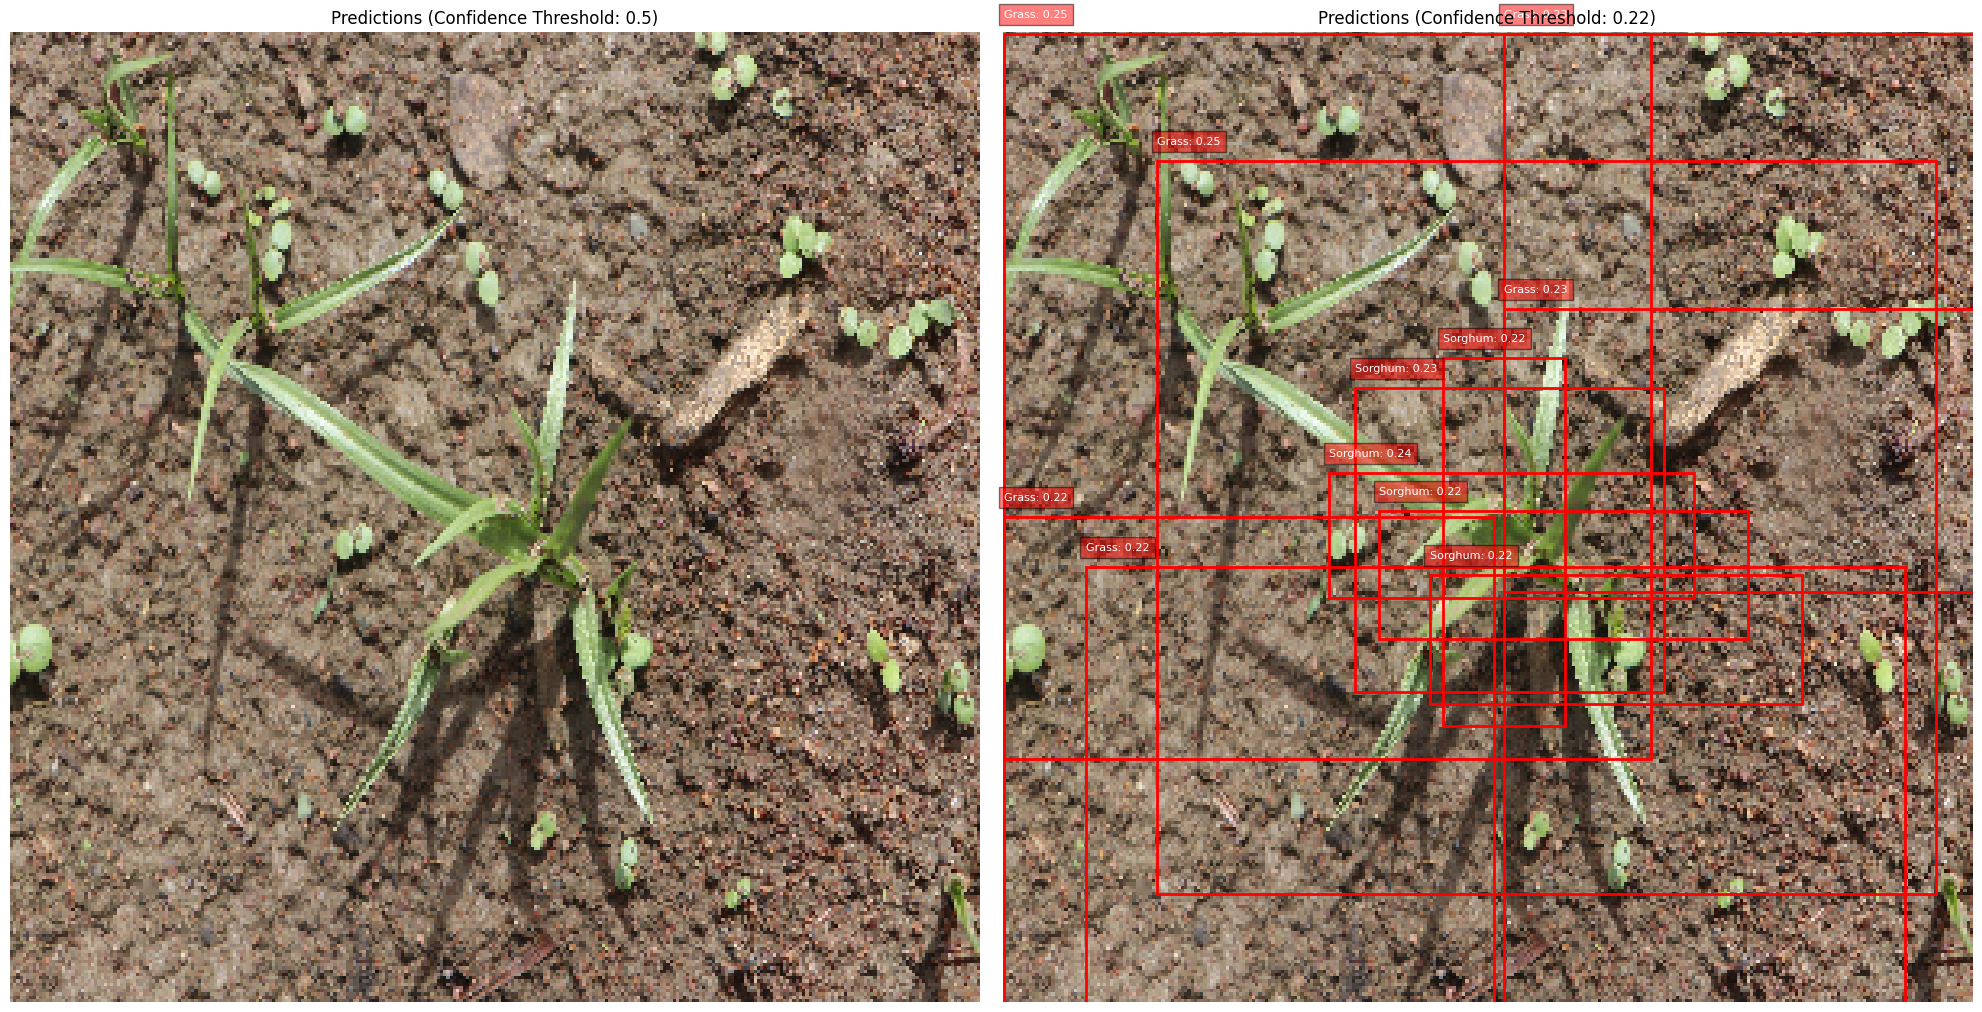

In [84]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_predictions(ax, image_tensor, decoded_boxes, predicted_labels, predicted_scores, class_names, score_threshold=0.5):
    # image_tensor: (C, H, W) PyTorch tensor, normalized
    # decoded_boxes: (N, 4) tensor in (ymin, xmin, ymax, xmax) normalized
    # predicted_labels: (N,) tensor
    # predicted_scores: (N,) tensor
    # class_names: list of class names (e.g., ['background', 'Grass', 'Sorghum', 'Weed'])
    # ax: matplotlib axes object for plotting

    # Convert image tensor to numpy array for plotting
    # Denormalize if necessary (e.g., multiply by 255 if normalized to [0,1])
    # Permute from C, H, W to H, W, C for matplotlib
    image_np = image_tensor.permute(1, 2, 0).cpu().numpy()
    if image_np.max() <= 1.0: # Assuming [0,1] normalization, convert to [0,255]
        image_np = (image_np * 255).astype(np.uint8)

    ax.imshow(image_np)

    # Filter predictions by score_threshold for visualization
    keep = predicted_scores > score_threshold
    boxes_to_plot = decoded_boxes[keep]
    labels_to_plot = predicted_labels[keep]
    scores_to_plot = predicted_scores[keep]

    # Iterate through each detected box and draw it
    for i in range(boxes_to_plot.shape[0]):
        ymin, xmin, ymax, xmax = boxes_to_plot[i].cpu().numpy()
        score = scores_to_plot[i].item()
        label_idx = labels_to_plot[i].item()

        # Convert normalized coordinates back to image pixels
        h, w, _ = image_np.shape
        xmin_pix, ymin_pix, xmax_pix, ymax_pix = xmin * w, ymin * h, xmax * w, ymax * h

        # Create a Rectangle patch
        rect = plt.Rectangle((xmin_pix, ymin_pix),
                             xmax_pix - xmin_pix,
                             ymax_pix - ymin_pix,
                             fill=False,
                             edgecolor='red',
                             linewidth=2)
        ax.add_patch(rect)

        # Add label and score
        label_text = f"{class_names[label_idx + 1]}: {score:.2f}" # +1 because class_names[0] is 'background'
        ax.text(xmin_pix, ymin_pix - 5,
                label_text,
                bbox=dict(facecolor='red', alpha=0.5),
                fontsize=8,
                color='white')

    ax.axis('off')
    ax.set_title(f"Predictions (Confidence Threshold: {score_threshold})")


# Set model to evaluation mode
pytorch_ssd_model.eval()

# Fetch a batch from the test loader
# We'll use the first image in the batch for demonstration
images, targets = next(iter(test_loader))

# Move images to device
images = images.to(device)

# Make predictions
with torch.no_grad():
    pred_class_logits_batch, pred_locations_batch = pytorch_ssd_model(images)

# Process and visualize predictions for the first image in the batch
if images.shape[0] > 0:
    img_tensor = images[0]
    # The model output has batch dimension, so take the first item
    pred_class_logits = pred_class_logits_batch[0]
    pred_locations = pred_locations_batch[0]

    # Define confidence thresholds for visualization
    confidence_threshold_1 = 0.5
    confidence_threshold_2 = 0.22

    # Post-process predictions for the first threshold
    final_boxes_1, final_labels_1, final_scores_1 = post_process_predictions(
        pred_class_logits, pred_locations, ssd_priors.to(device),
        confidence_threshold=confidence_threshold_1, iou_threshold=0.45, num_classes=num_classes_with_background
    )

    # Post-process predictions for the second threshold
    final_boxes_2, final_labels_2, final_scores_2 = post_process_predictions(
        pred_class_logits, pred_locations, ssd_priors.to(device),
        confidence_threshold=confidence_threshold_2, iou_threshold=0.45, num_classes=num_classes_with_background
    )

    print(f"Found {len(final_boxes_1)} detections with confidence threshold {confidence_threshold_1}.")
    print(f"Found {len(final_boxes_2)} detections with confidence threshold {confidence_threshold_2}.")

    # Create subplots for visualization
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))

    # Visualize for the first threshold
    visualize_predictions(axes[0], img_tensor, final_boxes_1, final_labels_1, final_scores_1, example_class_names, score_threshold=confidence_threshold_1)

    # Visualize for the second threshold
    visualize_predictions(axes[1], img_tensor, final_boxes_2, final_labels_2, final_scores_2, example_class_names, score_threshold=confidence_threshold_2)

    plt.tight_layout()
    plt.show()
else:
    print("No images in the test batch to process.")
